In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pa
from pyroomacoustics.doa import circ_dist
import soundfile as sf

In [2]:
# 音声データをロードし、指定された秒数とサンプリングレートでリサンプル
def load_audio_file(file_path, length, sample_rate=16000):
    data, sr = sf.read(file_path)
    # データが設定値よりも大きい場合は大きさを超えた分をカットする
    # データが設定値よりも小さい場合はデータの後ろを0でパディングする
    # シングルチャンネル(モノラル)の場合 (data.shape: [num_samples,])
    if data.ndim == 1:
        if len(data) > sample_rate*length:
            data = data[:sample_rate*length]
        else:
            data = np.pad(data, (0, max(0, sample_rate*length - len(data))), "constant")
        """data: (num_samples, )"""
    # マルチチャンネルの場合 (data.shape: [num_samples, num_channels])
    elif data.ndim == 2:
        if data.shape[0] > sample_rate*length:
            data = data[:sample_rate*length, :]
        else:
            data = np.pad(data, [(0, max(0, sample_rate*length-data.shape[0])), (0, 0)], "constant")
        """data: (num_samples, num_channels)"""
    else:
        print("number of audio channels are incorrect")
    return data

In [3]:
# 音声に室内インパルス応答（Room Impulse Response）を畳み込む
def rir_convolve(wave_file, sampling_rate, doas, distance_mic_to_source, \
                 mic_array_loc, R, room_dim, max_order, absorption, SNR, amp_decay=20):
    """
    wave_file: 入力音声のパス
    sampling_rate: サンプリング周波数[Hz]
    doas: 音源の到来方向
    distance_mic_to_source: 音源とマイクロホンの距離 [m]
    mic_array_loc: マイクロホンアレイの位置座標
    R: 各マイクロホンの空間的な座標
    room_dim: 部屋の３次元形状を表す（単位はm）
    max_order: 部屋の壁で何回音が反射するか（反射しない場合0）
    absorption: 部屋の壁でどの程度音が吸収されるか （吸収されない場合None）
    SNR: 音声と雑音の比率 [dB]
    amp_decay: 生成した音が割れないようにするための振幅調整用パラメータ
    """
    wave_files = [wave_file] # 後のためにリストに格納
    n_sources = len(wave_files)
#     print("音源数:", n_sources)
    source_locations = np.zeros((3, doas.shape[0]), dtype=doas.dtype)
    """source_locations: (xyz, num_sources)"""
    source_locations[0,  :] = np.cos(doas[:, 1]) * np.cos(doas[:, 0]) # x = rcosφcosθ
    source_locations[1,  :] = np.sin(doas[:, 1]) * np.cos(doas[:, 0]) # y = rsinφcosθ
    source_locations[2,  :] = np.sin(doas[:, 0]) # z = rsinθ
    source_locations *= distance_mic_to_source
    source_locations += mic_array_loc[:, None] # マイクロホンアレイからの相対位置→絶対位置
    for i in range(n_sources):
        x = source_locations[0, i]
        y = source_locations[1, i]
        z = source_locations[2, i]
#         print("{}個目の音源の位置： (x, y, z) = ({}, {}, {})".format(i+1, x, y, z))
    # 音声波形の長さを調べる
    n_samples = 0
    # ファイルを読み込む
    for wave_file in wave_files:
        wav = wave.open(wave_file)
        if n_samples<wav.getnframes():
            n_samples=wav.getnframes()
        wav.close()
    clean_data = np.zeros([n_sources, n_samples])
    # ファイルを読み込む
    s = 0
    for wave_file in wave_files:
        wav = wave.open(wave_file)
        data = wav.readframes(wav.getnframes())
        data = np.frombuffer(data, dtype=np.int16)
        data = data/np.iinfo(np.int16).max
        clean_data[s, :wav.getnframes()] = data
        wav.close()
        s = s+1
    # 部屋を生成する
    room = pa.ShoeBox(room_dim, fs=sampling_rate, max_order=max_order, absorption=absorption)
    # 用いるマイクロホンアレイの情報を設定する
    room.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
    # 各音源をシミュレーションに追加する
    for s in range(n_sources):
        clean_data[s] /= np.std(clean_data[s])
        room.add_source(source_locations[:, s], signal=clean_data[s])
    # RIRのシミュレーション生成と音源信号への畳み込みを実行
    room.simulate(snr=SNR)
    # convolved_wave = room.mic_array.signals.T/np.max(room.mic_array.signals.T)
    convolved_wave = room.mic_array.signals.T * np.iinfo(np.int16).max / amp_decay
#     print("畳み込み後の音声波形:", convolved_wave.shape)
    # インパルス応答の取得と残響時間（RT60）の取得
    impulse_responses = room.rir
    rt60 = pa.experimental.measure_rt60(impulse_responses[0][0], fs=sampling_rate)
#     print("残響時間:{} [sec]".format(rt60))
    
    return convolved_wave

部屋の3次元形状： [5. 5. 5.]
マイクロホンアレイ中心座標： [2.5  2.5  0.53]
マイクロホン数： 8
MUSIC
Recovered azimuth: [0.] degrees
Error: [60.] degrees


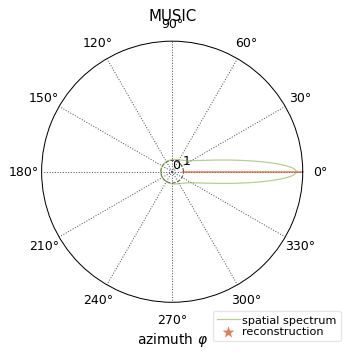

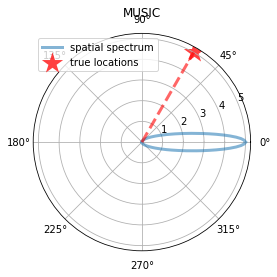

In [4]:
if __name__ == "__main__":
    convolved_wave_path = "../audio_separation/data/multichannel_audio_for_test/p232_007_target.wav"
    # convolved_wave_path = "../audio_separation/data/multichannel_audio_for_test/p232_007_mixed.wav"
    # convolved_wave_path = "../../speech_denoising_MCDUnet/output/wave/p232_007_ckpt_NoisySpeechDataset_fft_512_kernel3_multi_1108/estimated_voice.wav" # モデルで処理後の音声
    audio_length = 3
    sample_rate = 16000
    fft_size = 512
    freq_range = [300, 3500]
    c = 343. # speed of sound
    algo_name = 'MUSIC'

    # 音源方向（音源が複数ある場合はリストに追加）
    azimuth = [np.pi/3] # 方位角
    elevation = [np.pi/6] # 仰角
    # 部屋（シミュレーション環境）の設定
    room_width = 5.0
    room_length = 5.0
    room_height = 5.0
    # 部屋の３次元形状を表す（単位はm）
    room_dim = np.r_[room_width, room_length, room_height]
    print("部屋の3次元形状：", room_dim)
    # マイクロホンアレイの中心位置
    nakbot_height = 0.57 # Nakbotの全長
    mic_array_height = nakbot_height - 0.04 # 0.04はTAMAGO-03マイクロホンアレイの頂上部からマイクロホンアレイ中心までの距離
    mic_array_loc = np.r_[room_width/2, room_length/2, 0] + [0, 0, mic_array_height] # 部屋の中央に配置されたNakbot上のマイクロホンアレイ
    print("マイクロホンアレイ中心座標：", mic_array_loc)
    # TAMAGO-03のマイクロホンアレイのマイクロホン配置（単位はm）
    mic_alignments = np.array(
    [
        [0.035, 0.0, 0.0],
        [0.035/np.sqrt(2), 0.035/np.sqrt(2), 0.0],
        [0.0, 0.035, 0.0],
        [-0.035/np.sqrt(2), 0.035/np.sqrt(2), 0.0],
        [-0.035, 0.0, 0.0],
        [-0.035/np.sqrt(2), -0.035/np.sqrt(2), 0.0],
        [0.0, -0.035, 0.0],
        [0.035/np.sqrt(2), -0.035/np.sqrt(2), 0.0]
    ])
    n_channels = np.shape(mic_alignments)[0]
    print("マイクロホン数：", n_channels)
    # get the microphone array （各マイクロホンの空間的な座標）
    R = mic_alignments.T + mic_array_loc[:, None]
    """R: (3D coordinates [m], num_microphones)"""
    # 音源の位置（HARK座標系に対応） [仰角θ, 方位角φ]
    doas = np.array(
    [[elevation[0], azimuth[0]], # １個目の音源 
    # [elevation[1], azimuth[1]] # ２個目の音源
    ])

    convolved_wave_data = load_audio_file(convolved_wave_path, audio_length, sample_rate)
    convolved_spec = pa.transform.stft.analysis(convolved_wave_data, fft_size, fft_size // 2)
    convolved_spec = convolved_spec.transpose([2, 1, 0])
    print(convolved_spec.shape)

    # Construct the new DOA object
    # the max_four parameter is necessary for FRIDA only
    doa = pa.doa.algorithms[algo_name](R, sample_rate, fft_size, c=c, num_src=1)

    # this call here perform localization on the frames in X
    doa.locate_sources(convolved_spec, freq_range=freq_range)

    doa.polar_plt_dirac()
    plt.title(algo_name)

    # doa.azimuth_recon contains the reconstructed location of the source
    print(algo_name)
    print("Recovered azimuth:", doa.azimuth_recon / np.pi * 180.0, "degrees")
    print("Error:", circ_dist(azimuth, doa.azimuth_recon) / np.pi * 180.0, "degrees")

    plt.show()

    # 別の描画方法
    # store spatial response
    spatial_resp = doa.grid.values
    """spatial_resp: (360, )"""

    # normalize
    min_val = spatial_resp.min()
    max_val = spatial_resp.max()
    spatial_resp = (spatial_resp - min_val) / (max_val - min_val)
    """spatial_resp: (360, )"""

    # plot
    # plotting param
    base = 0
    height = 5
    true_col = [1, 0, 0]
    phi_plt = doa.grid.azimuth
    """phi_plt: (360, )"""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='polar')
    c_phi_plt = np.r_[phi_plt, phi_plt[0]]
    """c_phi_plt: (361, )"""
    c_dirty_img = np.r_[spatial_resp, spatial_resp[0]]
    """c_dirty_img: (361, )"""
    ax.plot(c_phi_plt, base + height * c_dirty_img, linewidth=3,
            alpha=0.55, linestyle='-',
            label="spatial spectrum")
    plt.title(algo_name)

    # plot true loc
    for angle in azimuth:
        ax.plot([angle, angle], [base, base + height], linewidth=3, linestyle='--',
            color=true_col, alpha=0.6)
        # ax.plot([angle], [base], linewidth=3, linestyle='--',
        #     color=true_col, alpha=0.6)
    K = len(azimuth)
    ax.scatter(azimuth, base + height*np.ones(K), c=np.tile(true_col,
               (K, 1)), s=500, alpha=0.75, marker='*',
               linewidths=0,
               label='true locations')
    plt.legend()

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles, labels, framealpha=0.5,
    #           scatterpoints=1, loc='center right', fontsize=16,
    #           ncol=1, bbox_to_anchor=(1.6, 0.5),
    #           handletextpad=.2, columnspacing=1.7, labelspacing=0.1)
    # ax.set_xticks(np.linspace(0, 2 * np.pi, num=12, endpoint=False))
    # ax.xaxis.set_label_coords(0.5, -0.11)
    # ax.set_yticks(np.linspace(0, 1, 2))
    # ax.xaxis.grid(b=True, color=[0.3, 0.3, 0.3], linestyle=':')
    # ax.yaxis.grid(b=True, color=[0.3, 0.3, 0.3], linestyle='--')
    # ax.set_ylim([0, 1.05 * (base + height)])





In [ ]:
__